Assigment Module 2

In [5]:
import os
import numpy as np
import pandas as pd

from datetime import datetime
from tqdm import tqdm
from scipy.stats import ttest_ind

import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [28]:
path = "/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/"

flist = [os.path.join(path, name) for path, subdirs, files in os.walk(path) for name in files]
for i in range(0,5):
    print(flist[i])

# exclude first 2 items, not relevant
flist = flist[2:]

print('\n', flist[0:5])
nst = len(flist)
print("\n > Number of stations = ", nst)

/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/Index
/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/616120
/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/612913
/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/612770
/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/614010

 ['/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/612913', '/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/612770', '/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/614010', '/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/618470', '/Users/farabiisa/Downloads/CRUTEM.4.6.0.0.station_files/61/614420']

 > Number of stations =  10295


In [29]:
metadata0 = pd.DataFrame(columns=['ID','stname','country','elev','lat','lon'])

taxis = pd.date_range('1850-01', '2019-01', freq='M')
nmonths = len(taxis)
nyears = int(nmonths / 12)

data0 = pd.DataFrame({'time': taxis})
data0 = data0.set_index(['time'])

yref0 = 1961
yref1 = 1990

/var/folders/50/lynv2mgd4ml0_67zqxm5wnwm0000gn/T/ipykernel_61662/3588047745.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  taxis = pd.date_range('1850-01', '2019-01', freq='M')


In [ ]:
nodatacount = 0
tooshortcount = 0
outsidecount = 0

for si in tqdm(range(0, nst)):

    filein = flist[si]

    with open(filein, encoding='latin-1', errors='ignore') as f:
        data = f.readlines()

    if "Obs:\n" not in data:
        nodatacount += 1
        continue

    skipi = data.index("Obs:\n") + 1

    if (len(data) - skipi < 2):
        nodatacount += 1
        continue

    try:
        yr = np.genfromtxt(filein, skip_header=skipi, usecols=0, dtype='i4')
    except:
        continue

    if np.size(yr) == 0:
        continue

    if np.ndim(yr) == 0:
        yr = np.array([yr])

    if len(yr) < 30:
        tooshortcount += 1
        continue

    norm_line = [line for line in data if "Normals=" in line]
    if len(norm_line) == 0:
        outsidecount += 1
        continue

    norm = str(norm_line).split("=",1)[1]
    norm = norm[:-4].strip()

    if "-99.0" in norm:
        outsidecount += 1
        continue

    # metadata
    stname = str([l for l in data if "Name=" in l]).split("=")[1][:-4].strip()
    country = str([l for l in data if "Country=" in l]).split("=")[1][:-4].strip()
    elev = float(str([l for l in data if "Height=" in l]).split("=")[1][:-4].strip())
    lat = float(str([l for l in data if "Lat=" in l]).split("=")[1][:-4].strip())
    lon = float(str([l for l in data if "Long=" in l]).split("=")[1][:-4].strip())

    metadata0 = pd.concat([metadata0, pd.DataFrame([{
        "ID": filein[-6:],
        "stname": stname,
        "country": country,
        "elev": elev,
        "lat": lat,
        "lon": lon
    }])], ignore_index=True)

    # data
    ti0 = datetime.strptime(str(yr[0]), "%Y")
    ti1 = datetime.strptime(str(yr[-1] + 1), "%Y")

    stime = pd.date_range(ti0, ti1, freq='ME')

    loc_data = np.genfromtxt(filein, skip_header=skipi, filling_values='-99.0')[:,1:13]
    loc_data = loc_data.flatten()

    station_id = filein[-6:]

    if station_id in data0.columns: 
        continue

    xdf = pd.DataFrame({'time': stime, station_id: loc_data}).set_index('time')
    data0 = data0.join(xdf, how='left')

  0%|          | 0/10295 [00:00<?, ?it/s]/var/folders/50/lynv2mgd4ml0_67zqxm5wnwm0000gn/T/ipykernel_61662/914381585.py:56: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  metadata0 = pd.concat([metadata0, pd.DataFrame([{
100%|██████████| 10295/10295 [04:16<00:00, 40.10it/s]


In [31]:
data0[data0 == -99.0] = np.nan

metadata0 = metadata0.set_index('ID')
metadata0.lon = -metadata0.lon
metadata0 = metadata0[~metadata0.index.duplicated(keep='first')]

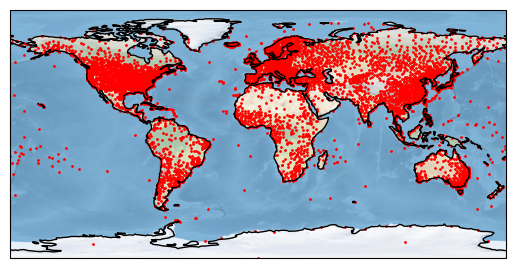

In [32]:
ax = plt.axes(projection=ccrs.PlateCarree())
ax.coastlines()
ax.stock_img()
ax.scatter([metadata0.lon],[metadata0.lat],color='r',marker='o',s=1.0)
plt.show()

In [33]:
ref_data = data0.loc['1961-01-31':'1990-12-31']
data_normals = ref_data.groupby(ref_data.index.month).mean()

In [34]:
data_anom = data0.copy()

y0 = 0
for yi in range(0, nyears):
    data_anom.iloc[y0:y0+12,:] = data0.iloc[y0:y0+12,:] - np.array(data_normals)
    y0 += 12

In [35]:
resol = 20

nlon = int(360 / resol)
nlat = int(180 / resol)

grlons = np.linspace(-180, 180, nlon+1)
grlats = np.linspace(-90, 90, nlat+1)

In [36]:
data_mo = np.full((nmonths, nlat, nlon), np.nan)
data_yr = np.full((nyears, nlat, nlon), np.nan)

In [37]:
for j in range(nlat):
    for i in range(nlon):

        dummy = metadata0[
            (metadata0.lon >= grlons[i]) &
            (metadata0.lon < grlons[i+1]) &
            (metadata0.lat >= grlats[j]) &
            (metadata0.lat < grlats[j+1])
        ]

        if len(dummy) > 0:
            cell_series = data_anom[dummy.index].mean(axis=1)

            data_mo[:,j,i] = cell_series.values
            data_yr[:,j,i] = cell_series.resample("YE").mean().values